# Census 2011 Population Data Analysis

## Dataset Introduction

This project uses Census 2011 population data of Indian States and Union Territories.

The dataset contains demographic information including total population, male population, female population, age-group population, and other population-related indicators.

The dataset is analyzed using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn to identify population patterns and demographic differences across States and Union Territories.

## Project Objective

The main objective of this project is to analyze population distribution and demographic patterns across Indian States and Union Territories using Census 2011 data.

The analysis focuses on:
- State-wise population distribution
- Male and female population comparison
- Sex ratio analysis
- Population differences across States/UTs
- Statistical analysis and outlier detection
- Data visualization to identify meaningful demographic patterns

## Tools and Technologies

- Python
- Pandas – Data cleaning and data analysis
- NumPy – Numerical calculations
- Matplotlib – Data visualization
- Seaborn – Statistical data visualization
- Jupyter Notebook – Development environment

In [2]:
import xlrd
import pandas as pd
df=pd.read_excel(r"C:\Users\rajpu\Downloads\PCA0000_2011_MDDS.xls")
print("file readed successfully".title())


File Readed Successfully


## Data Understanding

In [3]:
df.head()

,State Code,District Code,Subdistt Code,Town/Village Code,State Code.1,District Code.1,Subdistt Code.1,Town/Village Code.1,Ward Code,EB Code,...,Marginal Agriculture Labourers Population 0_3 Female,Marginal Household Industries Population 0_3 Person,Marginal Household Industries Population 0_3 Male,Marginal Household Industries Population 0_3 Female,Marginal Other Workers Population 0_3 Person,Marginal Other Workers Population 0_3 Male,Marginal Other Workers Population 0_3 Female,Non Working Population Person,Non Working Population Male,Non Working Population Female
0,0,0,0,0,0,0,0,0,0,0,...,5820265,1420217,491353,928864,5517396,3082038,2435358,728826262,291255913,437570349
1,0,0,0,0,0,0,0,0,0,0,...,5640684,1154844,386006,768838,3802346,1971773,1830573,484865913,200869575,283996338
2,0,0,0,0,0,0,0,0,0,0,...,179581,265373,105347,160026,1715050,1110265,604785,243960349,90386338,153574011
3,1,0,0,0,1,0,0,0,0,0,...,44570,26585,6780,19805,108457,56880,51577,8218589,3445572,4773017
4,1,0,0,0,1,0,0,0,0,0,...,40936,21963,5757,16206,89232,45625,43607,5994979,2562471,3432508


In [4]:
df.drop(df.columns[0:10],axis=1,inplace=True)
df.head(5)

,Level,Name,TRU,No of Households,Total Population Person,Total Population Male,Total Population Female,Population in the age group 0-6 Person,Population in the age group 0-6 Male,Population in the age group 0-6 Female,...,Marginal Agriculture Labourers Population 0_3 Female,Marginal Household Industries Population 0_3 Person,Marginal Household Industries Population 0_3 Male,Marginal Household Industries Population 0_3 Female,Marginal Other Workers Population 0_3 Person,Marginal Other Workers Population 0_3 Male,Marginal Other Workers Population 0_3 Female,Non Working Population Person,Non Working Population Male,Non Working Population Female
0,India,India,Total,249454252,1210569573,623121843,587447730,164478150,85732470,78745680,...,5820265,1420217,491353,928864,5517396,3082038,2435358,728826262,291255913,437570349
1,India,India,Rural,168565486,833463448,427632643,405830805,121285762,63064665,58221097,...,5640684,1154844,386006,768838,3802346,1971773,1830573,484865913,200869575,283996338
2,India,India,Urban,80888766,377106125,195489200,181616925,43192388,22667805,20524583,...,179581,265373,105347,160026,1715050,1110265,604785,243960349,90386338,153574011
3,STATE,JAMMU & KASHMIR,Total,2119718,12541302,6640662,5900640,2018905,1084355,934550,...,44570,26585,6780,19805,108457,56880,51577,8218589,3445572,4773017
4,STATE,JAMMU & KASHMIR,Rural,1553433,9108060,4774477,4333583,1593008,854141,738867,...,40936,21963,5757,16206,89232,45625,43607,5994979,2562471,3432508


In [5]:
for i,col in enumerate(df.columns):
    print(i,col)

0 Level
1 Name
2 TRU
3 No of Households
4 Total Population Person
5 Total Population Male
6 Total Population Female
7 Population in the age group 0-6 Person
8 Population in the age group 0-6 Male
9 Population in the age group 0-6 Female
10 Scheduled Castes population Person
11 Scheduled Castes population Male
12 Scheduled Castes populationFemale
13 Scheduled Tribes population Person
14 Scheduled Tribes population Male
15 Scheduled Tribes population Female
16 Literates Population Person
17 Literates Population Male
18 Literates Population Female
19 Illiterate Persons
20 Illiterate Male
21 Illiterate Female
22 Total Worker Population Person
23 Total Worker Population Male
24 Total Worker Population Female
25 Main Working Population Person
26 Main Working Population Male
27 Main Working Population Female
28 Main Cultivator Population Person
29 Main Cultivator Population Male
30 Main Cultivator Population Female
31 Main Agricultural Labourers Population Person
32 Main Agricultural Labourer

## Data Cleaning

In [6]:
df.duplicated().sum().sum()

np.int64(0)

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.isna().sum().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.columns=df.columns.str.strip()#colums mdhla unwanted space clear kela

In [11]:
df=df.apply(lambda x:x.str.strip() if x.dtype=="object" else x)

In [12]:
df.dtypes

Level                                           object
Name                                            object
TRU                                             object
No of Households                                 int64
Total Population Person                          int64
                                                 ...  
Marginal Other Workers Population 0_3 Male       int64
Marginal Other Workers Population 0_3 Female     int64
Non Working Population Person                    int64
Non Working Population Male                      int64
Non Working Population Female                    int64
Length: 88, dtype: object

In [14]:
df.select_dtypes(include="object").shape# apn ase column shodhle jyancha datatype object ahe karn kdhi kdhi number text madhe pn asu shakta

(108, 3)

In [15]:
df.select_dtypes(include=['int64','float64']).shape

(108, 85)

In [16]:
df.select_dtypes(include=['int64','float64']).min().sum()# kontya minmum value ahet te tapasnyasathi

np.int64(105059)

In [17]:
(df.select_dtypes(include=['int64','float64'])<0).sum()#data mdhe negative value nahi ahet

No of Households                                0
Total Population Person                         0
Total Population Male                           0
Total Population Female                         0
Population in the age group 0-6 Person          0
                                               ..
Marginal Other Workers Population 0_3 Male      0
Marginal Other Workers Population 0_3 Female    0
Non Working Population Person                   0
Non Working Population Male                     0
Non Working Population Female                   0
Length: 85, dtype: int64

In [18]:
df.describe().T.head(5)

,count,mean,std,min,25%,50%,75%,max
No of Households,108.0,9.239046e+06,2.978042e+07,2710.0,205626.50,1683600.5,7785008.25,2.494543e+08
Total Population Person,108.0,4.483591e+07,1.453840e+08,14141.0,893298.75,8975081.5,34750316.75,1.210570e+09
Total Population Male,108.0,2.307859e+07,7.481990e+07,7243.0,452179.00,4747602.5,17490733.25,6.231218e+08
Total Population Female,108.0,2.175732e+07,7.056632e+07,6898.0,441119.75,4227479.0,17380076.50,5.874477e+08
Population in the age group 0-6 Person,108.0,6.091783e+06,2.012720e+07,1815.0,93214.25,1113163.0,4519701.25,1.644782e+08


In [27]:
df.rename(columns={
    "Total Population Person":"Total Population",
    "Total Population Male":"Male Population",
    "Total Population Female":"Female Population"
    
},inplace=True)

In [28]:
df.columns.duplicated().sum()# yachane aplyala samjte ki ekandha column duplicate ahe ka


np.int64(0)

In [29]:
df.head(5)

,Level,Name,TRU,No of Households,Total Population,Male Population,Female Population,Population in the age group 0-6 Person,Population in the age group 0-6 Male,Population in the age group 0-6 Female,...,Marginal Agriculture Labourers Population 0_3 Female,Marginal Household Industries Population 0_3 Person,Marginal Household Industries Population 0_3 Male,Marginal Household Industries Population 0_3 Female,Marginal Other Workers Population 0_3 Person,Marginal Other Workers Population 0_3 Male,Marginal Other Workers Population 0_3 Female,Non Working Population Person,Non Working Population Male,Non Working Population Female
0,India,India,Total,249454252,1210569573,623121843,587447730,164478150,85732470,78745680,...,5820265,1420217,491353,928864,5517396,3082038,2435358,728826262,291255913,437570349
1,India,India,Rural,168565486,833463448,427632643,405830805,121285762,63064665,58221097,...,5640684,1154844,386006,768838,3802346,1971773,1830573,484865913,200869575,283996338
2,India,India,Urban,80888766,377106125,195489200,181616925,43192388,22667805,20524583,...,179581,265373,105347,160026,1715050,1110265,604785,243960349,90386338,153574011
3,STATE,JAMMU & KASHMIR,Total,2119718,12541302,6640662,5900640,2018905,1084355,934550,...,44570,26585,6780,19805,108457,56880,51577,8218589,3445572,4773017
4,STATE,JAMMU & KASHMIR,Rural,1553433,9108060,4774477,4333583,1593008,854141,738867,...,40936,21963,5757,16206,89232,45625,43607,5994979,2562471,3432508


In [30]:
df.shape

(108, 88)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 88 columns):
 #   Column                                                Non-Null Count  Dtype 
---  ------                                                --------------  ----- 
 0   Level                                                 108 non-null    object
 1   Name                                                  108 non-null    object
 2   TRU                                                   108 non-null    object
 3   No of Households                                      108 non-null    int64 
 4   Total Population                                      108 non-null    int64 
 5   Male Population                                       108 non-null    int64 
 6   Female Population                                     108 non-null    int64 
 7   Population in the age group 0-6 Person                108 non-null    int64 
 8   Population in the age group 0-6 Male                  108 non-null    

## Exploratory Data Analysis (EDA)

### Population Overview

In [32]:
df[["TRU"]].value_counts()

TRU  
Rural    36
Total    36
Urban    36
Name: count, dtype: int64

In [40]:
state_df=df[
    (df["TRU"]=="Total")&
    (df["Name"]!="India")
]

In [44]:
state_df[["Name","Total Population "]]

,Name,Total Population
3,JAMMU & KASHMIR,12541302
6,HIMACHAL PRADESH,6864602
9,PUNJAB,27743338
12,CHANDIGARH,1055450
15,UTTARAKHAND,10086292
18,HARYANA,25351462
21,NCT OF DELHI,16787941
24,RAJASTHAN,68548437
27,UTTAR PRADESH,199812341
30,BIHAR,104099452


In [46]:
top_10=state_df.sort_values(
    by="Total Population ",
    ascending=False
).head(10)

In [47]:
top_10[["Name","Total Population "]]

,Name,Total Population
27,UTTAR PRADESH,199812341
81,MAHARASHTRA,112374333
30,BIHAR,104099452
57,WEST BENGAL,91276115
84,ANDHRA PRADESH,84580777
69,MADHYA PRADESH,72626809
99,TAMIL NADU,72147030
24,RAJASTHAN,68548437
87,KARNATAKA,61095297
72,GUJARAT,60439692


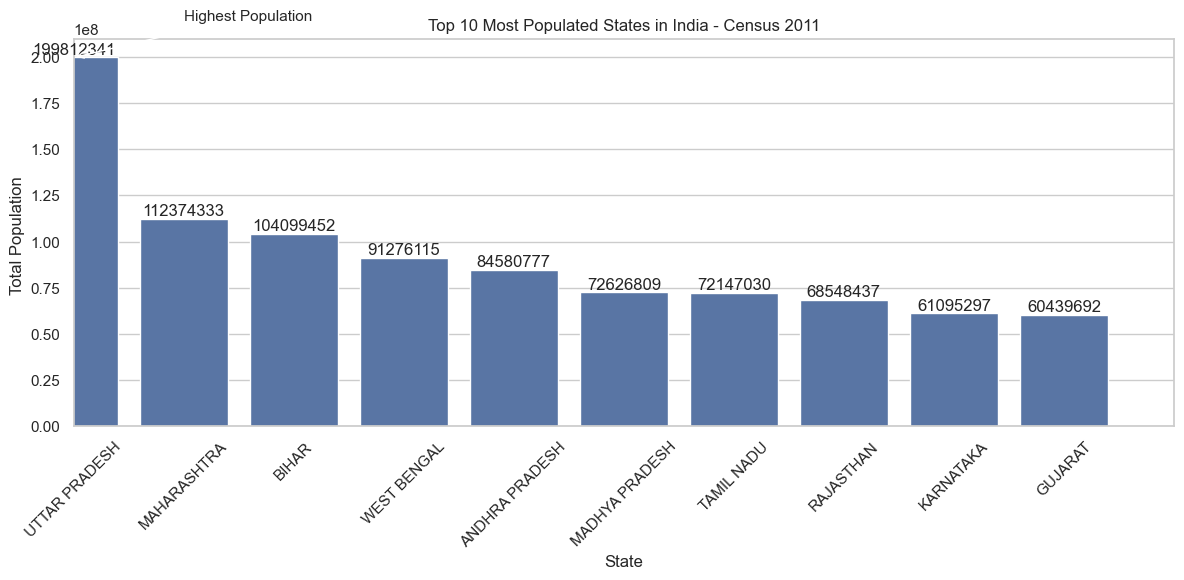

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.set_theme(
    style="whitegrid",
    context='notebook'
)
ax=sns.barplot(
    data=top_10,
    x="Name",
    y="Total Population "
)
ax.bar_label(ax.containers[0], fmt="%.0f")
ax.annotate(
    "Highest Population",
    xy=(0, top_10["Total Population "].iloc[0]),
    xytext=(1, top_10["Total Population "].iloc[0] + 20000000),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)
 
plt.title("Top 10 Most Populated States in India - Census 2011")
plt.xlabel("State")
plt.ylabel("Total Population ")
plt.xlim(0,10)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Top 10 Most Populated States/UTs

In [49]:
state_df=df[
    (df["TRU"]=="Total")&
    (df["Name"]!="India")
]
state_df[["Name","Total Population "]]

,Name,Total Population
3,JAMMU & KASHMIR,12541302
6,HIMACHAL PRADESH,6864602
9,PUNJAB,27743338
12,CHANDIGARH,1055450
15,UTTARAKHAND,10086292
18,HARYANA,25351462
21,NCT OF DELHI,16787941
24,RAJASTHAN,68548437
27,UTTAR PRADESH,199812341
30,BIHAR,104099452


In [50]:
top_10=state_df.sort_values(
    by="Total Population ",
    ascending=False
).head(10)
top_10[["Name","Total Population "]]


,Name,Total Population
27,UTTAR PRADESH,199812341
81,MAHARASHTRA,112374333
30,BIHAR,104099452
57,WEST BENGAL,91276115
84,ANDHRA PRADESH,84580777
69,MADHYA PRADESH,72626809
99,TAMIL NADU,72147030
24,RAJASTHAN,68548437
87,KARNATAKA,61095297
72,GUJARAT,60439692


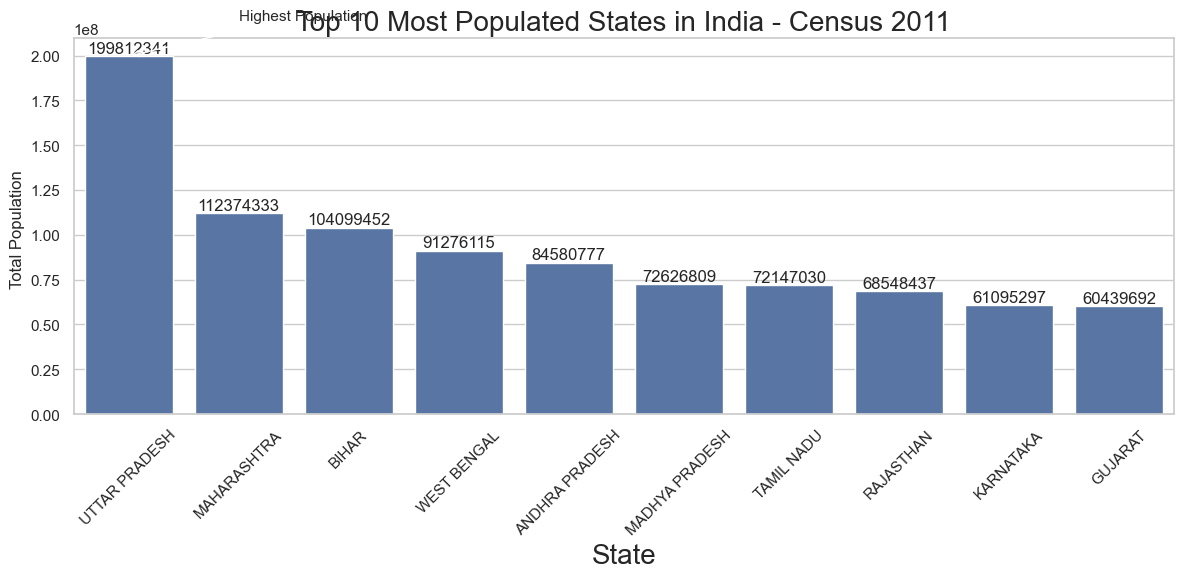

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

ax = sns.barplot(
    data=top_10,
    x="Name",
    y="Total Population "
)

ax.bar_label(ax.containers[0], fmt="%.0f")

ax.annotate(
    "Highest Population",
    xy=(0, top_10["Total Population "].iloc[0]),
    xytext=(1, top_10["Total Population "].iloc[0] + 20000000),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

plt.title("Top 10 Most Populated States in India - Census 2011",fontsize=20)
plt.xlabel("State",fontsize=20)
plt.ylabel("Total Population ")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


## Graph 2: Male vs Female Population

In [52]:

male_female=top_10[
    ["Name","Male Population","Female Population"]
]
    
male_female

,Name,Male Population,Female Population
27,UTTAR PRADESH,104480510,95331831
81,MAHARASHTRA,58243056,54131277
30,BIHAR,54278157,49821295
57,WEST BENGAL,46809027,44467088
84,ANDHRA PRADESH,42442146,42138631
69,MADHYA PRADESH,37612306,35014503
99,TAMIL NADU,36137975,36009055
24,RAJASTHAN,35550997,32997440
87,KARNATAKA,30966657,30128640
72,GUJARAT,31491260,28948432


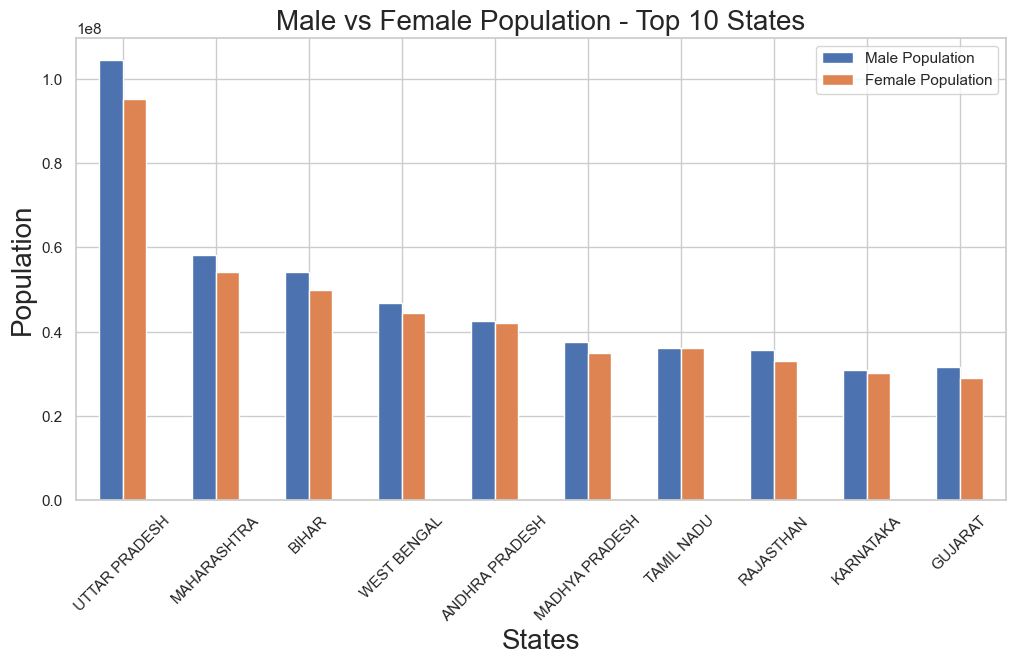

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
male_female=top_10[
    ["Name","Male Population","Female Population"]
]
male_female.plot(
    x="Name",
    kind="bar",
    figsize=(12,6)
)
plt.title("Male vs Female Population - Top 10 States",fontsize=20)
plt.xlabel("States",fontsize=20)
plt.ylabel("Population",fontsize=20)
plt.xticks(rotation=45)
plt.show()

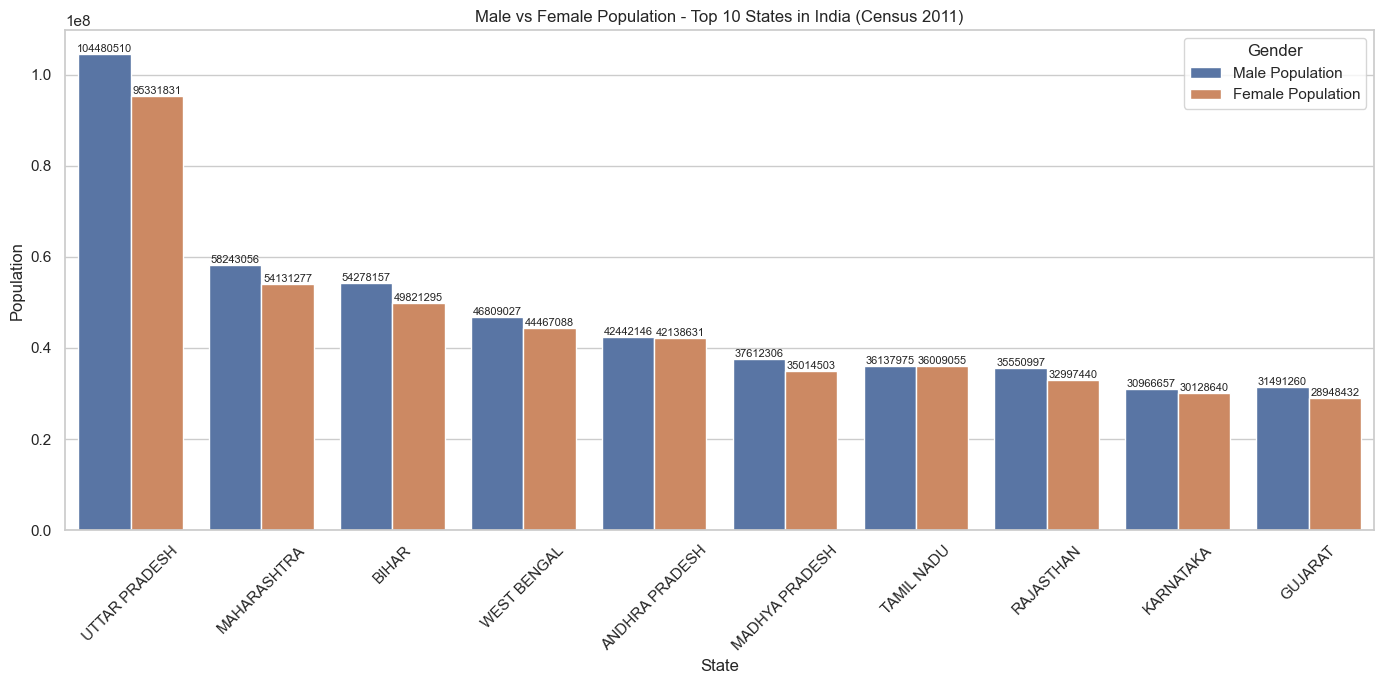

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data reshape krne
male_female_long = male_female.melt(#melt cha upayog dataframe cha structure badalnyasathi hot asto
    id_vars="Name",
    value_vars=[#apn sangto ki hya don variable la melt kr
        "Male Population",#he dogh eka navin column mdhe yetil
        "Female Population"
    ],
    var_name="Gender",# male ani female cha value jya navin column madhe jatil tyacha naav
    value_name="Population"#male ani female che actual values jya column madhe yetil tya columns che nav
)

# Graph
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=male_female_long,
    x="Name",
    y="Population",
    hue="Gender"
)

# Bar vr values
for container in ax.containers:# ya mdhe graph madhle br group asta aplya graph mdhe  hue=gender ahet mhnun don group ahet
    ax.bar_label(
        container,
        fmt="%.0f",
        fontsize=8
    )

plt.title("Male vs Female Population - Top 10 States in India (Census 2011)")
plt.xlabel("State")
plt.ylabel("Population")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### male female difference 

In [55]:

male_female["population_difference"]=(
    male_female["Male Population"]
    -male_female["Female Population"]
)
male_female[[
    "Name",
    "Male Population",
    "Female Population",
    "population_difference"
]].sort_values(
    by="population_difference",
    ascending=False
)


C:\Users\rajpu\AppData\Local\Temp\ipykernel_2668\4186339514.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  male_female["population_difference"]=(


,Name,Male Population,Female Population,population_difference
27,UTTAR PRADESH,104480510,95331831,9148679
30,BIHAR,54278157,49821295,4456862
81,MAHARASHTRA,58243056,54131277,4111779
69,MADHYA PRADESH,37612306,35014503,2597803
24,RAJASTHAN,35550997,32997440,2553557
72,GUJARAT,31491260,28948432,2542828
57,WEST BENGAL,46809027,44467088,2341939
87,KARNATAKA,30966657,30128640,838017
84,ANDHRA PRADESH,42442146,42138631,303515
99,TAMIL NADU,36137975,36009055,128920


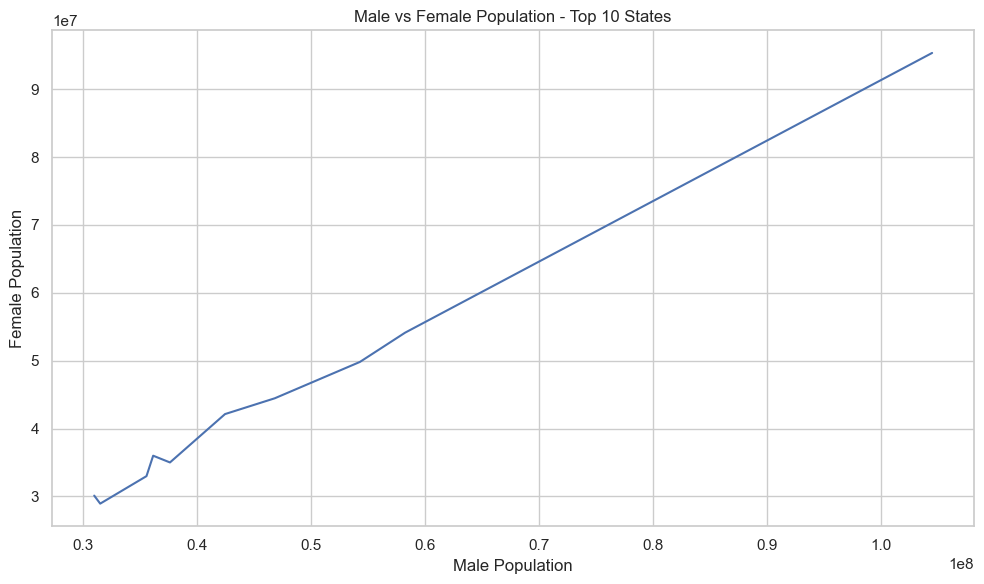

In [56]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=male_female,
    x="Male Population",
    y="Female Population",
    
)

plt.title("Male vs Female Population - Top 10 States")
plt.xlabel("Male Population")
plt.ylabel("Female Population")

plt.tight_layout()
plt.show()

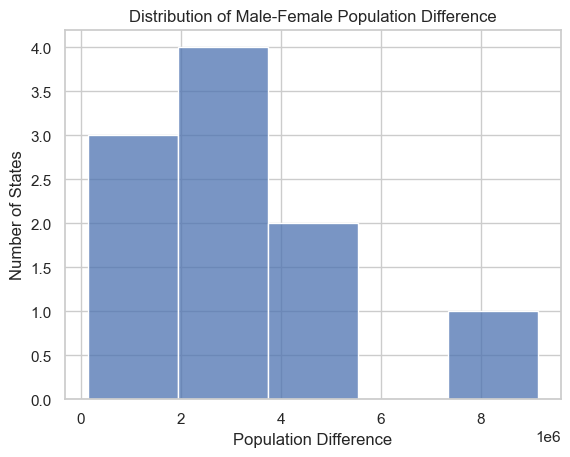

In [57]:
sns.histplot(
    data=male_female,
    x="population_difference",
    bins=5
)

plt.title("Distribution of Male-Female Population Difference")
plt.xlabel("Population Difference")
plt.ylabel("Number of States")

plt.show()

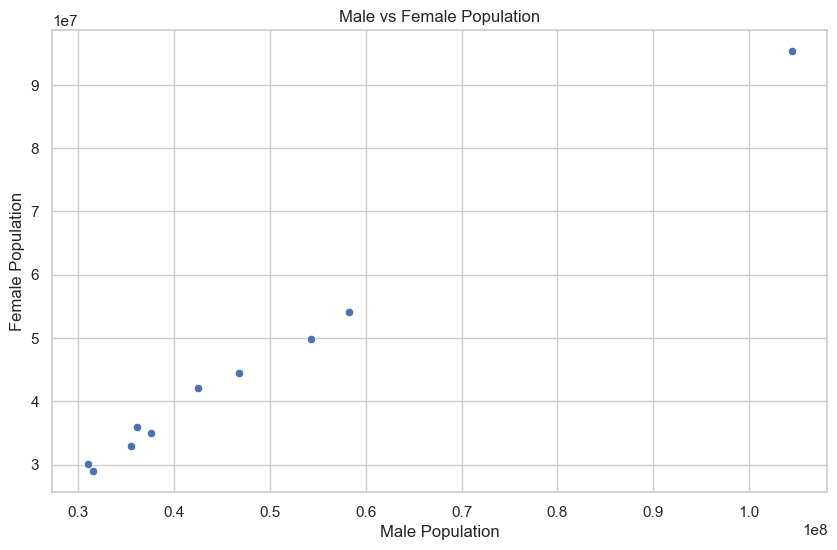

In [58]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=male_female,
    x="Male Population",
    y="Female Population"
)

plt.title("Male vs Female Population")
plt.xlabel("Male Population")
plt.ylabel("Female Population")

plt.show()
#yanchat positive relation ahe -male population vadhli mhnje female population pn vadhte
#population size cha strong pattern disto-populatio jast ahe tithe male female population jasyt ahe
# dots jvlpas eka upword direction madhe dist ahet -mhnaje stron posistive correlatiom ahet
#srvat varcha dot ha sarvat jadt male female aslela population cha state darshavto


### male v/s female correlation

In [59]:
male_female[
    ["Male Population","Female Population"]
].corr()
# ekdam strong positive corelation ahe j darshavte ki strong  male populated area madhe female population pn jast ahe

,Male Population,Female Population
Male Population,1.000000,0.998415
Female Population,0.998415,1.000000


### sex ratio analysis

In [60]:

male_female["sex ratio"]=(
    male_female["Male Population"]/
    male_female["Female Population"]
)*1000
male_female.sort_values(
    by="sex ratio",
    ascending=False
)


C:\Users\rajpu\AppData\Local\Temp\ipykernel_2668\553794270.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  male_female["sex ratio"]=(


,Name,Male Population,Female Population,population_difference,sex ratio
27,UTTAR PRADESH,104480510,95331831,9148679,1095.966677
30,BIHAR,54278157,49821295,4456862,1089.456968
72,GUJARAT,31491260,28948432,2542828,1087.839922
24,RAJASTHAN,35550997,32997440,2553557,1077.386518
81,MAHARASHTRA,58243056,54131277,4111779,1075.959394
69,MADHYA PRADESH,37612306,35014503,2597803,1074.192200
57,WEST BENGAL,46809027,44467088,2341939,1052.666795
87,KARNATAKA,30966657,30128640,838017,1027.814631
84,ANDHRA PRADESH,42442146,42138631,303515,1007.202773
99,TAMIL NADU,36137975,36009055,128920,1003.580211


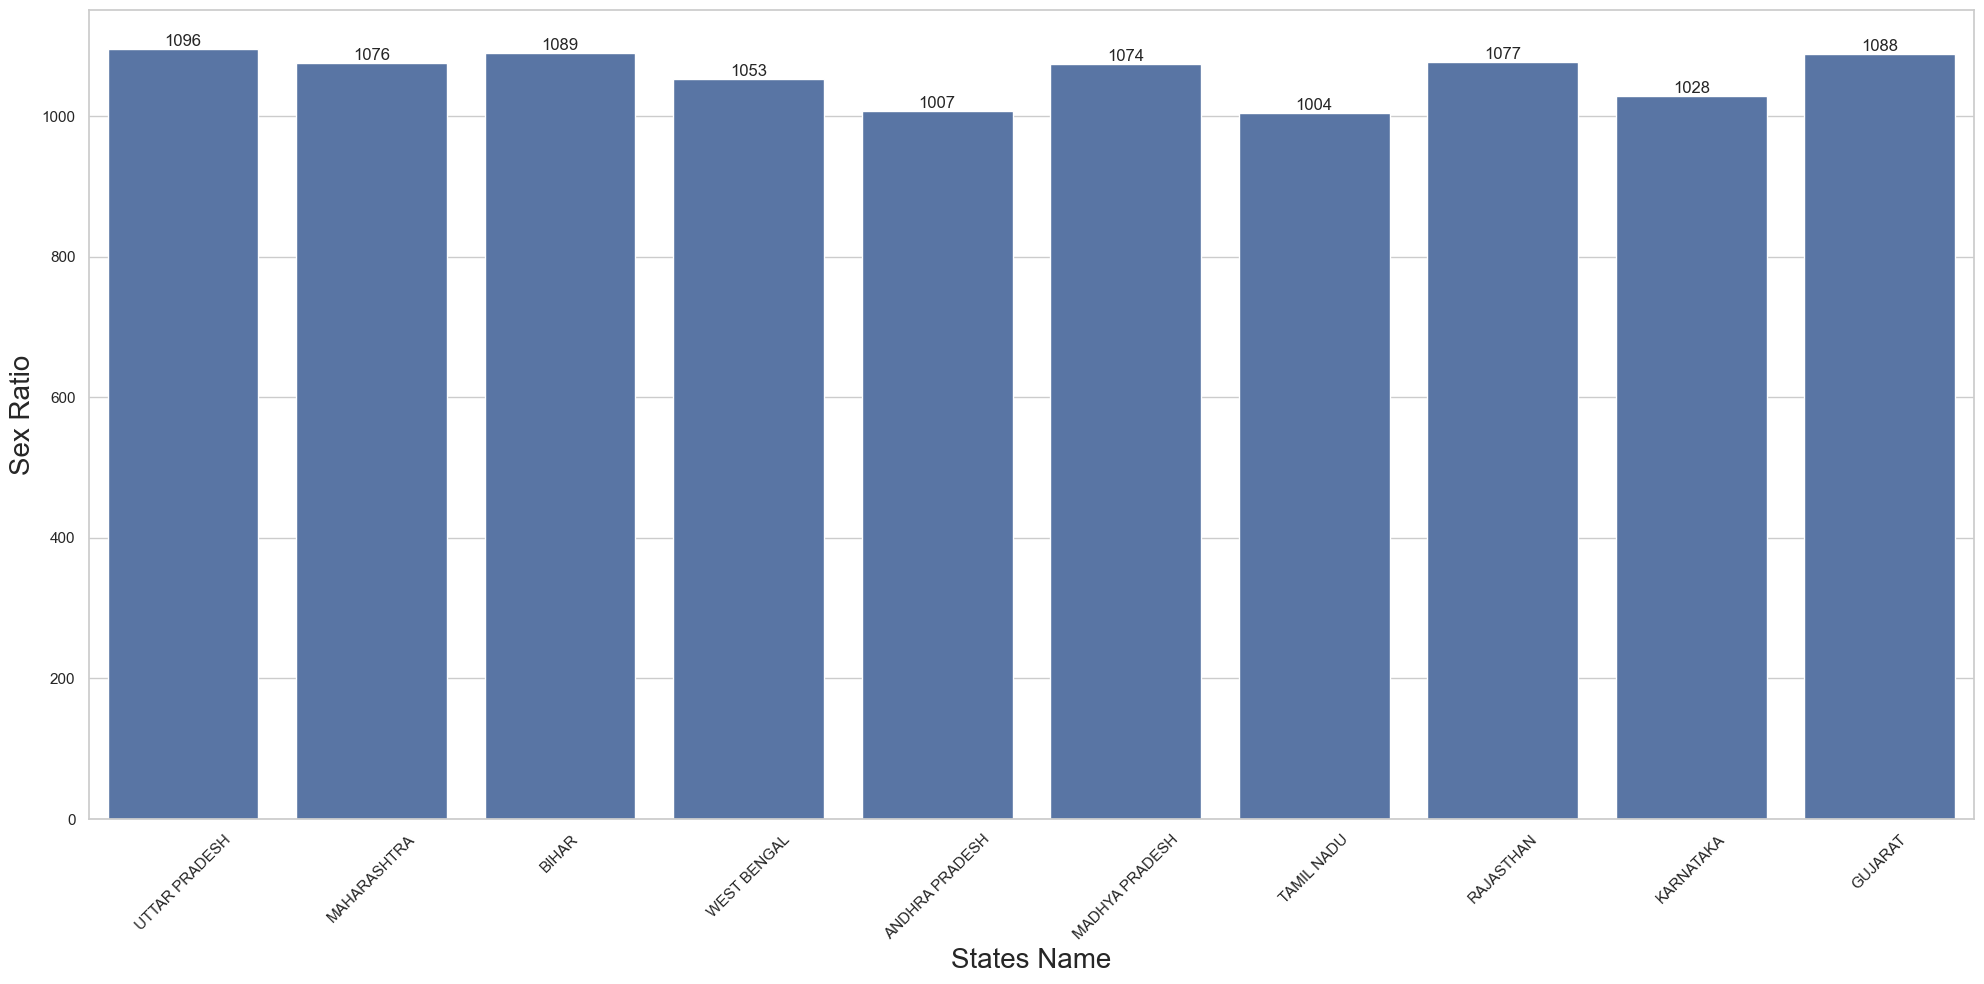

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,10))
sns.set_theme(
    style="whitegrid"
)
ax=sns.barplot(
    data=male_female,
    x="Name",
    y="sex ratio"
)
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.xlabel("States Name",fontsize=20)
plt.ylabel("Sex Ratio",fontsize=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### male vs female percentage analysis

In [62]:

male_female["total population "]=(  #ethe apn total population navacha 1 navin column banavla
    male_female['Male Population']+
    male_female["Female Population"]
)
male_female

C:\Users\rajpu\AppData\Local\Temp\ipykernel_2668\3159874987.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  male_female["total population "]=(  #ethe apn total population navacha 1 navin column banavla


,Name,Male Population,Female Population,population_difference,sex ratio,total population
27,UTTAR PRADESH,104480510,95331831,9148679,1095.966677,199812341
81,MAHARASHTRA,58243056,54131277,4111779,1075.959394,112374333
30,BIHAR,54278157,49821295,4456862,1089.456968,104099452
57,WEST BENGAL,46809027,44467088,2341939,1052.666795,91276115
84,ANDHRA PRADESH,42442146,42138631,303515,1007.202773,84580777
69,MADHYA PRADESH,37612306,35014503,2597803,1074.192200,72626809
99,TAMIL NADU,36137975,36009055,128920,1003.580211,72147030
24,RAJASTHAN,35550997,32997440,2553557,1077.386518,68548437
87,KARNATAKA,30966657,30128640,838017,1027.814631,61095297
72,GUJARAT,31491260,28948432,2542828,1087.839922,60439692


In [63]:
male_female['male%']=(
    male_female["Male Population"]/
    male_female["total population "]
)*100
male_female

C:\Users\rajpu\AppData\Local\Temp\ipykernel_2668\3346918361.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  male_female['male%']=(


,Name,Male Population,Female Population,population_difference,sex ratio,total population,male%
27,UTTAR PRADESH,104480510,95331831,9148679,1095.966677,199812341,52.289318
81,MAHARASHTRA,58243056,54131277,4111779,1075.959394,112374333,51.829501
30,BIHAR,54278157,49821295,4456862,1089.456968,104099452,52.140675
57,WEST BENGAL,46809027,44467088,2341939,1052.666795,91276115,51.282887
84,ANDHRA PRADESH,42442146,42138631,303515,1007.202773,84580777,50.179423
69,MADHYA PRADESH,37612306,35014503,2597803,1074.192200,72626809,51.788460
99,TAMIL NADU,36137975,36009055,128920,1003.580211,72147030,50.089345
24,RAJASTHAN,35550997,32997440,2553557,1077.386518,68548437,51.862593
87,KARNATAKA,30966657,30128640,838017,1027.814631,61095297,50.685828
72,GUJARAT,31491260,28948432,2542828,1087.839922,60439692,52.103608


In [64]:
male_female['female%']=(
    male_female["Female Population"]/
    male_female["total population "]
)*100
male_female

C:\Users\rajpu\AppData\Local\Temp\ipykernel_2668\4250905136.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  male_female['female%']=(


,Name,Male Population,Female Population,population_difference,sex ratio,total population,male%,female%
27,UTTAR PRADESH,104480510,95331831,9148679,1095.966677,199812341,52.289318,47.710682
81,MAHARASHTRA,58243056,54131277,4111779,1075.959394,112374333,51.829501,48.170499
30,BIHAR,54278157,49821295,4456862,1089.456968,104099452,52.140675,47.859325
57,WEST BENGAL,46809027,44467088,2341939,1052.666795,91276115,51.282887,48.717113
84,ANDHRA PRADESH,42442146,42138631,303515,1007.202773,84580777,50.179423,49.820577
69,MADHYA PRADESH,37612306,35014503,2597803,1074.192200,72626809,51.788460,48.211540
99,TAMIL NADU,36137975,36009055,128920,1003.580211,72147030,50.089345,49.910655
24,RAJASTHAN,35550997,32997440,2553557,1077.386518,68548437,51.862593,48.137407
87,KARNATAKA,30966657,30128640,838017,1027.814631,61095297,50.685828,49.314172
72,GUJARAT,31491260,28948432,2542828,1087.839922,60439692,52.103608,47.896392


In [65]:
male_female[
    ["Name",'male%',"female%"]
]

,Name,male%,female%
27,UTTAR PRADESH,52.289318,47.710682
81,MAHARASHTRA,51.829501,48.170499
30,BIHAR,52.140675,47.859325
57,WEST BENGAL,51.282887,48.717113
84,ANDHRA PRADESH,50.179423,49.820577
69,MADHYA PRADESH,51.788460,48.211540
99,TAMIL NADU,50.089345,49.910655
24,RAJASTHAN,51.862593,48.137407
87,KARNATAKA,50.685828,49.314172
72,GUJARAT,52.103608,47.896392


In [66]:
#male ani female percentage ekach graph madhe compare krna santhi data la long formate mdhe convert kru
percentage_data=male_female[
    ["Name",'male%',"female%"]
].melt(
    id_vars="Name",#yane male ani female name la ekatra kela
    var_name="Gender",#1 gender navacha column banvla v tyat male female la add kela
    value_name="Percentage"#1 percentage navacha column banavla v mal v female che column tytat ekatra kele
)
percentage_data

,Name,Gender,Percentage
0,UTTAR PRADESH,male%,52.289318
1,MAHARASHTRA,male%,51.829501
2,BIHAR,male%,52.140675
3,WEST BENGAL,male%,51.282887
4,ANDHRA PRADESH,male%,50.179423
5,MADHYA PRADESH,male%,51.788460
6,TAMIL NADU,male%,50.089345
7,RAJASTHAN,male%,51.862593
8,KARNATAKA,male%,50.685828
9,GUJARAT,male%,52.103608


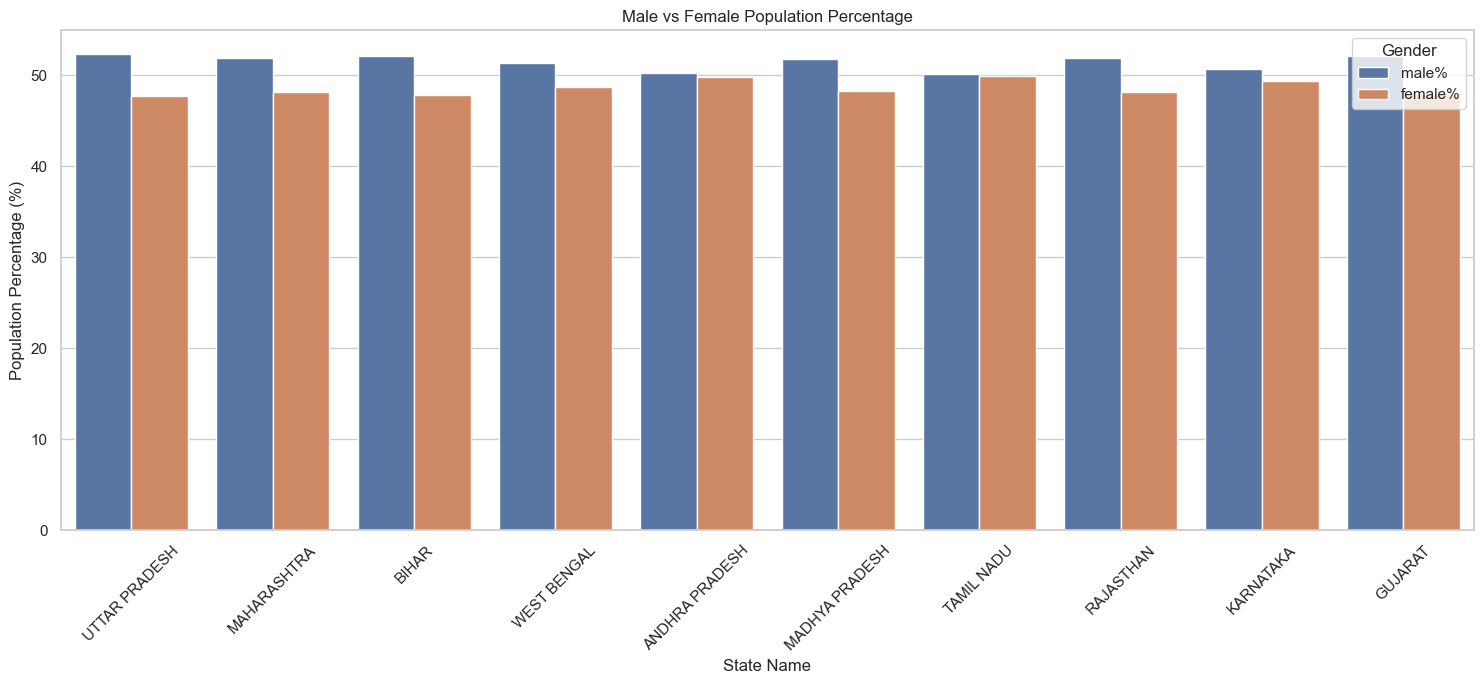

In [67]:
plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=percentage_data,
    x="Name",
    y="Percentage",
    hue="Gender"
)

plt.title("Male vs Female Population Percentage")
plt.xlabel("State Name")
plt.ylabel("Population Percentage (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### top 10 state cha populatio share anlysis

In [68]:
 
total_india_population=df["Total Population "].sum()
total_india_population

np.int64(4842278292)

In [69]:
top_10_population=top_10["Total Population "].sum()
top_10_population

np.int64(927000283)

In [70]:
top_10_share=(
    top_10_population/
    total_india_population
)*100
top_10_share

np.float64(19.143886970137817)

In [71]:
remaining_share=100-top_10_share
remaining_share

np.float64(80.85611302986219)

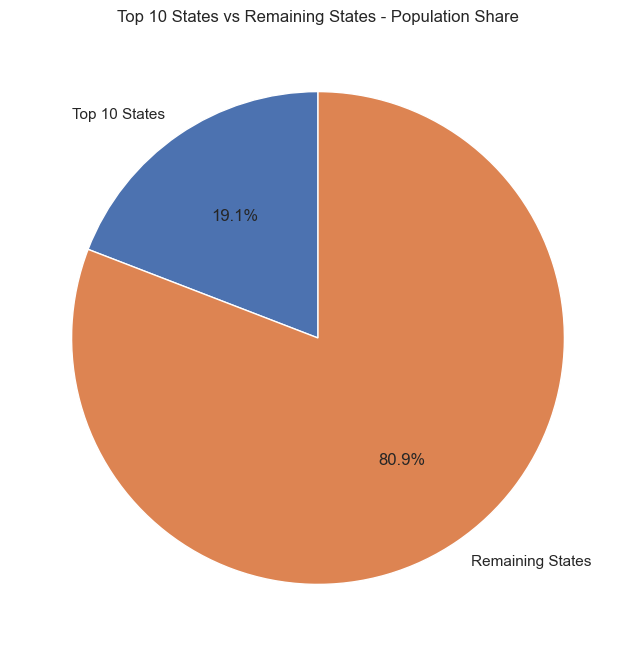

In [72]:
import matplotlib.pyplot as plt

labels = [
    "Top 10 States",
    "Remaining States"
]

values = [
    top_10_share,
    remaining_share
]

plt.figure(figsize=(8, 8))

plt.pie(
    values,
    labels=labels,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Top 10 States vs Remaining States - Population Share")

plt.show()

# Full Dataset Distribution

### population distribution cha histograam

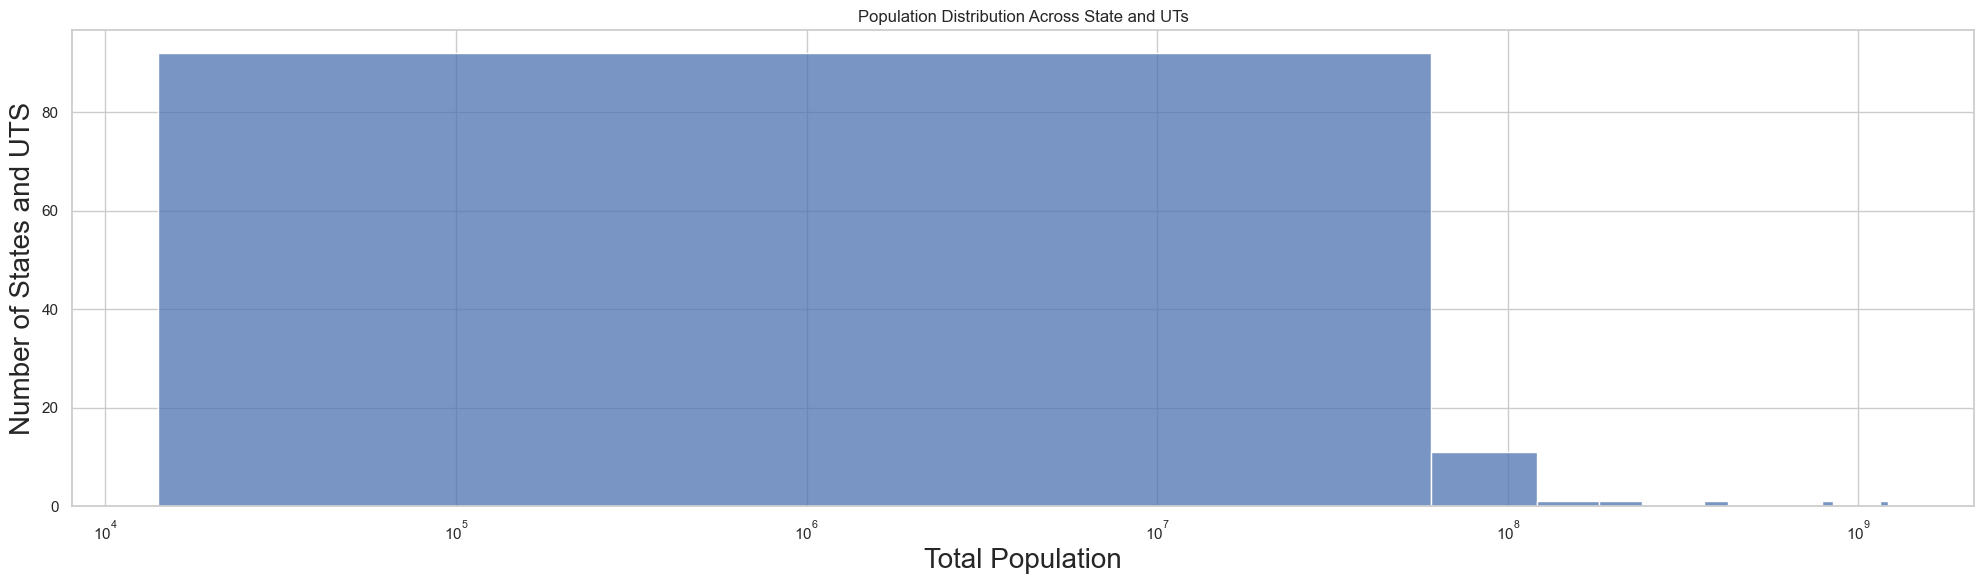

In [73]:

plt.figure(figsize=(20,6))
sns.histplot(
    data=df,
    x="Total Population ",
    bins=20
)
plt.title("Population Distribution Across State and UTs")
plt.xlabel("Total Population",fontsize=20)
plt.ylabel("Number of States and UTS",fontsize=20)
plt.xscale("log")
plt.tight_layout()
plt.show()
#left side la motha bar ahe-mhanje dataset mdhe ashe khup states ahet jyancha population kami te madhyam ahe
#rigt side cha bar-khup jast population aslele states far kami ahet
#pattern-aplya dta right skewed disat ahe mhnje bahutek state chi population kami te madhyam swaprupat cha he
#mhanje aplya state cha population kami te madhyam swarupat ahet
#aplya data madhe 50% peksha jast states chi population median peksha kami ahe bt large states like up and mh tyancha avererage 4.4cr evdha krta yacha artha hach ki aplla dta rigkt skewed ahe


### population statistics

In [74]:
population_stats=df["Total Population "].agg(
    ["mean","median","min","max"]
)
population_stats
#average population of states=4.48 cr
#median=8.97 lakh
#max population=12.1 cr
# min population=14,141 population

mean      4.483591e+07
median    8.975082e+06
min       1.414100e+04
max       1.210570e+09
Name: Total Population , dtype: float64

In [75]:
df["Total Population "].std()

145384045.63551053

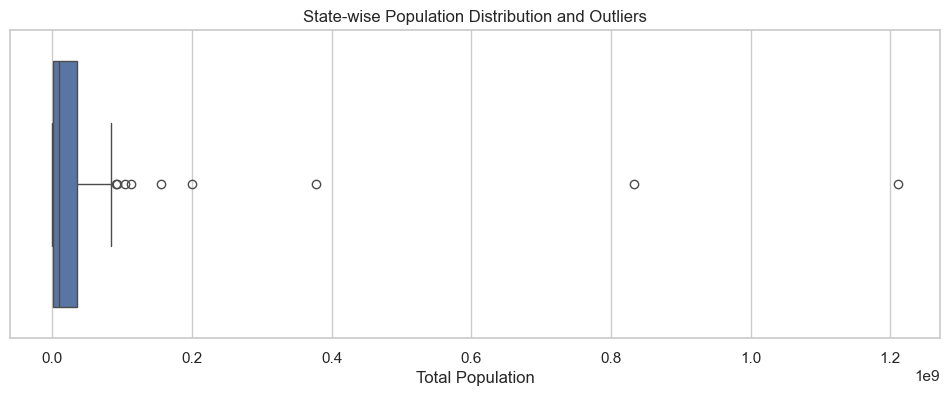

In [76]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df["Total Population "]
)

plt.title("State-wise Population Distribution and Outliers")
plt.xlabel("Total Population")

plt.show()

तुझ्या Graph मध्ये काय दिसतंय?

X-axis: Total Population
→ राज्यांची population दाखवली आहे.
→ शेवटी 1.2e8 म्हणजे 120 million = 12 crore नाही; इथे scientific notation मुळे 1.2 × 10⁸ = 120 million = 12 crore असा scale आहे.
महत्त्वाचे: तुझ्या आधीच्या comment मध्ये max = 121 cr लिहिलं असेल तर ते 121 crore नाही, तर सुमारे 12.1 crore (121 million) असण्याची शक्यता आहे. Dataset मध्ये जर फक्त states/UTs असतील तर हे तपासणे महत्त्वाचे आहे.

📦 Box म्हणजे काय?

Graph मधला डावीकडचा निळा box म्हणजे data मधील मधल्या 50% states ची population range.

━ Box मधली line

ही Median आहे.

तुझ्या आधीच्या calculation नुसार:

Median ≈ 8.97 lakh

म्हणजे 50% states ची population median पेक्षा कमी आणि 50% states ची population median पेक्षा जास्त आहे.

○ बाहेरचे गोल dots

हे potential outliers आहेत.

म्हणजे या states ची population बाकीच्या majority states पेक्षा खूप जास्त आहे.

Graph मध्ये उजवीकडे सर्वात लांब असलेला dot हा सर्वात जास्त population असलेला state आहे—बहुधा Uttar Pradesh.

🧠 मुख्य निष्कर्ष

तुझ्या graph वरून आपल्याला दिसते की:

बहुतेक states ची population तुलनेने कमी range मध्ये आहे, पण काही मोठ्या states ची population खूप जास्त आहे. त्यामुळे distribution right-skewed आहे आणि Mean हा Median पेक्षा खूप मोठा आहे.

### top 10 populated state

In [77]:

df_total=df[
    (df["TRU"]=="Total")&
    (df["Name"]!="India")
    
].copy()

In [78]:
top_10=df_total.nlargest(
    10,
    "Total Population "
)[[
    "Name",
    "Total Population "
]]
top_10


,Name,Total Population
27,UTTAR PRADESH,199812341
81,MAHARASHTRA,112374333
30,BIHAR,104099452
57,WEST BENGAL,91276115
84,ANDHRA PRADESH,84580777
69,MADHYA PRADESH,72626809
99,TAMIL NADU,72147030
24,RAJASTHAN,68548437
87,KARNATAKA,61095297
72,GUJARAT,60439692


In [79]:
bottom_10=df_total.nsmallest(
    10,
    "Total Population "
)[[
    "Name",
    "Total Population "
]]
bottom_10

,Name,Total Population
93,LAKSHADWEEP,64473
75,DAMAN & DIU,243247
78,DADRA & NAGAR HAVELI,343709
105,ANDAMAN & NICOBAR ISLANDS,380581
33,SIKKIM,610577
12,CHANDIGARH,1055450
45,MIZORAM,1097206
102,PUDUCHERRY,1247953
36,ARUNACHAL PRADESH,1383727
90,GOA,1458545


### #top 10 v/s bottom 10 numerical comparison 

In [80]:

top_10_total=top_10["Total Population "].sum()
top_10_total

np.int64(927000283)

In [81]:
bottom_10_total=bottom_10["Total Population "].sum()
bottom_10_total

np.int64(7885468)

In [82]:
top_10_average = top_10["Total Population "].mean()
top_10_average

np.float64(92700028.3)

In [84]:
bottom_10_average = bottom_10["Total Population "].mean()
bottom_10_average

np.float64(788546.8)

In [85]:
#top 10 kiti mothe ahet
population_ratio=(
    top_10_total/bottom_10_total
)
population_ratio

np.float64(117.55805527332049)

### top 10 v/s bottom 10 average population

In [86]:

comparison_avg = pd.DataFrame({
    "Group": ["Top 10 States", "Bottom 10 States"],
    "Average Population": [
        top_10_average,
        bottom_10_average
    ]
})

comparison_avg

,Group,Average Population
0,Top 10 States,92700028.3
1,Bottom 10 States,788546.8


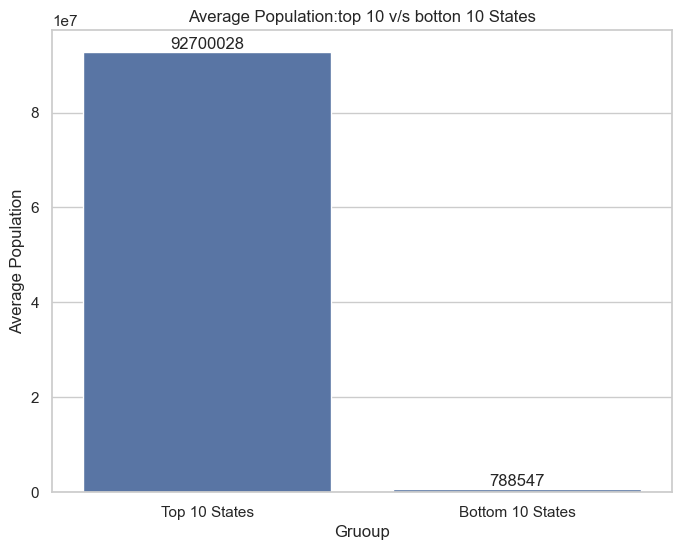

In [87]:
plt.figure(figsize=(8,6))
ax=sns.barplot(
    data=comparison_avg,
    x="Group",
    y="Average Population"
)
ax.bar_label(
    ax.containers[0],
    fmt="%.0f"
)
plt.title("Average Population:top 10 v/s botton 10 States")
plt.xlabel("Gruoup")
plt.ylabel("Average Population")
plt.show()

### data validation step

In [88]:

print("total rows:",len(df_total))#final data set chi basic mahiti ahe

total rows: 35


In [89]:
print('total State UTs:',df_total["Name"].nunique())

total State UTs: 35


In [90]:
df_total["Name"].value_counts().head(10)#duplicate na,es ahet ka te check krt ahot

Name
JAMMU & KASHMIR         1
MAHARASHTRA             1
ODISHA                  1
CHHATTISGARH            1
MADHYA PRADESH          1
GUJARAT                 1
DAMAN & DIU             1
DADRA & NAGAR HAVELI    1
ANDHRA PRADESH          1
WEST BENGAL             1
Name: count, dtype: int64

# project title
__Census 2011 Population Data Analysis using Python__
# objective-
To analyze population distribution, gender demographics, sex ratio, and population variations across Indian States and Union Territories using Census 2011 data.
# Tools & Technologies
1. Python
2. Pandas → Data cleaning आणि analysis
3. NumPy → Numerical calculations
4. Matplotlib → Data visualization
5. Seaborn → Statistical visualization
6. Jupyter Notebook
# Analysis Performed
1. State/UT-wise population analysis
2. Top 10 most populated States/UTs
3. Top 10 vs Remaining population share
4. Top 10 vs Bottom 10 comparison
5. Mean, Median, Minimum आणि Maximum population
6. Population distribution using Histogram
7. Log-scale population distribution
8. Outlier detection using IQR method
9. Male vs Female population analysis
10. Male-Female population difference
11. State-wise Sex Ratio analysis
12. Population vs Sex Ratio Scatter Plot
13. Correlation analysis
# Key Findings


- Population distribution across Indian States and Union Territories is highly uneven.
- A small number of highly populated states contribute a significant share of India's total population.
- Uttar Pradesh has the highest population among the Indian States in the dataset.
- Population data shows a right-skewed distribution due to the presence of highly populated states.
- The mean population is considerably higher than the median, indicating the influence of extreme population values.
- There is a substantial difference between male and female population across States and Union Territories.
- Sex ratios vary significantly across different States and Union Territories.
- The analysis shows that population size and sex ratio do not have a strong direct relationship.
- Outlier analysis identifies highly populated states as extreme observations compared with the majority of States and Union Territories.
- The Top 10 most populated States/UTs account for a significant proportion of the total population analyzed.
# Conclusion
This project demonstrates how Python-based data analysis and visualization techniques can be used to extract meaningful demographic insights from large government datasets.

# project overall conclusion
The Census 2011 analysis reveals significant variation in population size, gender distribution, and sex ratio across Indian States and Union Territories. Population is highly unevenly distributed, with a small number of highly populated states contributing a substantial share of India's population. Statistical analysis using mean, median, outliers, and visualizations highlights the skewed nature of population distribution, while gender and sex-ratio analysis provides insights into demographic differences across regions.